# IE 5533 Project:

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Environment Setup

In [27]:
!pip3.12 install geopy
!pip3.12 install ortools
!pip3.12 install xgboost
!pip3.12 install folium
!pip3.12 install openrouteservice

In [28]:
import json
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import xgboost as xgb
from ortools.linear_solver import pywraplp

from geopy.distance import geodesic

from matplotlib.patches import FancyArrowPatch
from geopy.distance import geodesic
from folium.plugins import PolyLineTextPath

## 2. Build the Attraction Utility Dataset

### 2.1 Load the Yelp Dataset

Total businesses: 150346
After city filter: 3829
After attraction filter: 325
                                                    name  stars  review_count  \
118248                                 Santa Barbara Zoo    4.0           681   
130633                            Sustainable Wine Tours    5.0           358   
23727                              Mission Santa Barbara    4.0           321   
142336                     Captain Jack's Tours & Events    4.5           310   
101468                               Celebration Cruises    4.5           297   
...                                                  ...    ...           ...   
132107                              Santa Barbara Harbor    4.5            32   
34124                                  Reid's Appliances    4.0            31   
19491                             Santa Barbara Mattress    4.0            31   
3835    El Presidio de Santa Bárbara State Historic Park    4.0            31   
16307                          

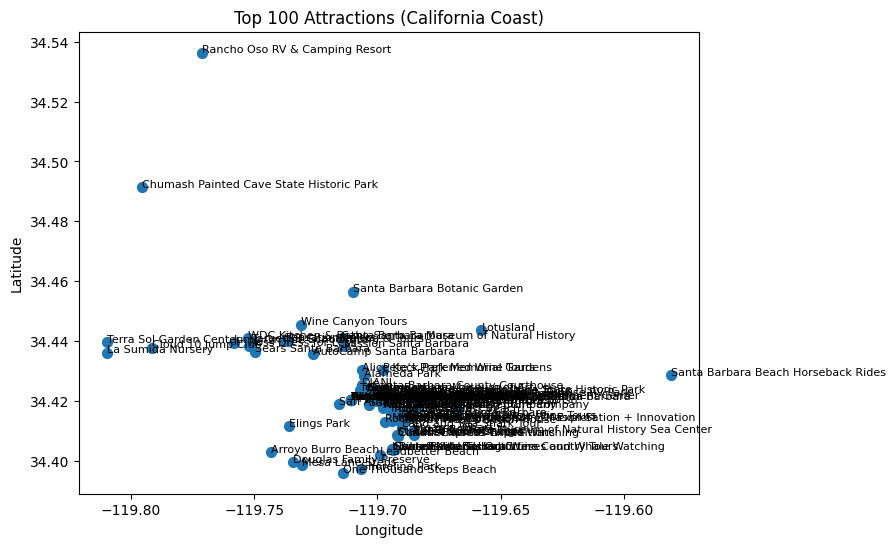

In [29]:
############################
# 1️⃣  LOAD YELP DATA
############################

file_path = "/content/drive/My Drive/IE_5533/yelp_academic_dataset_business.json"

records = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        obj = json.loads(line)

        # keep only necessary columns
        records.append({
            "business_id": obj["business_id"],
            "name": obj["name"],
            "city": obj["city"],
            "stars": obj["stars"],
            "review_count": obj["review_count"],
            "latitude": obj["latitude"],
            "longitude": obj["longitude"],
            "categories": obj["categories"]
        })

attractions_df = pd.DataFrame(records)

print("Total businesses:", len(attractions_df))


############################
# 2️⃣  FILTER CITY (California Coastal)
############################

attractions_df = attractions_df[attractions_df["city"].isin(["Santa Barbara", "Santa Cruz", "Monterey", "San Luis Obispo"])]

print("After city filter:", len(attractions_df))


############################
# 3️⃣  FILTER ATTRACTIONS
############################

category_pattern = (
    "Museum|Museums|Park|Parks|Garden|Aquarium|Zoo|"
    "Landmark|Historic|Monument|Observatory|Tour|Attraction|"
    "Beach|Botanical"
)

attractions_df = attractions_df[attractions_df["categories"].notna()]

attractions_df = attractions_df[attractions_df["categories"].str.contains(category_pattern, case=False, regex=True)]

print("After attraction filter:", len(attractions_df))

############################
# 4️⃣  COMPUTE UTILITY
############################

attractions_df["utility"] = attractions_df["stars"] * np.log(attractions_df["review_count"] + 1)


############################
# 5️⃣  SELECT TOP 100
############################

attractions_df = attractions_df.sort_values("review_count", ascending=False)

top100 = attractions_df.head(100)

print(top100[["name", "stars", "review_count", "utility"]])


############################
# 6️⃣  PLOT LOCATIONS
############################

plt.figure(figsize=(8,6))

plt.scatter(top100["longitude"], top100["latitude"], s=50)

for _, row in top100.iterrows():
    plt.text(row["longitude"], row["latitude"], row["name"], fontsize=8)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Top 100 Attractions (California Coast)")

plt.show()

## 3. Then we are gonna implement the Weather Dataset:

In [30]:
############################
# 1️⃣ GET CITY COORDINATES
############################

CITY = "Santa Barbara"

geo_url = "https://nominatim.openstreetmap.org/search"

geo_params = {
    "q": CITY,
    "format": "json",
    "limit": 1
}

headers = {
    "User-Agent": "IE5533-TravelPlanner/1.0"
}

geo_response = requests.get(geo_url, params=geo_params, headers=headers)

geo_data = geo_response.json()[0]

lat = float(geo_data["lat"])
lon = float(geo_data["lon"])

print("City:", CITY)
print("Latitude:", lat)
print("Longitude:", lon)

City: Santa Barbara
Latitude: 34.4221319
Longitude: -119.702667


In [31]:
############################
# 2️⃣ GET WEATHER DATA
############################

weather_url = "https://archive-api.open-meteo.com/v1/archive"

weather_params = {
    "latitude": lat,
    "longitude": lon,
    "start_date": "2001-01-01",
    "end_date": "2026-03-23",
    "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum",
    "timezone": "auto"
}

weather_response = requests.get(weather_url, params=weather_params)

weather_json = weather_response.json()

############################
# 3️⃣ Convert Weather Data to DataFrame
############################

weather_df = pd.DataFrame({
    "date": weather_json["daily"]["time"],
    "temp_max": weather_json["daily"]["temperature_2m_max"],
    "temp_min": weather_json["daily"]["temperature_2m_min"],
    "precipitation": weather_json["daily"]["precipitation_sum"]
})

weather_df["date"] = pd.to_datetime(weather_df["date"])
weather_df["date"] = (weather_df["date"]).dt.date

print(weather_df.head())

############################
# 4️⃣ WEATHER FEATURES
############################

weather_df["avg_temp"] = (
    weather_df["temp_max"] + weather_df["temp_min"]) / 2

weather_df["RainFlag"] = (weather_df["precipitation"] > 0).astype(int)

weather_df["ColdFlag"] = (weather_df["avg_temp"] < 5).astype(int)

weather_df["day_of_week"] = pd.to_datetime(weather_df["date"]).dt.dayofweek
weather_df["Weekend"] = (weather_df["day_of_week"] >= 5).astype(int)
weather_df.to_csv("santa_barbara_weather.csv", index=False)

weather_df["key"] = 1
attractions_df["key"] = 1

attraction_weather = weather_df.merge(attractions_df, on="key").drop("key", axis=1)

attraction_weather["day_of_week"] = pd.to_datetime(attraction_weather["date"]).dt.dayofweek
attraction_weather["weekend"] = (attraction_weather["day_of_week"] >= 5).astype(int)
attraction_weather.to_csv("attraction_weather_dataset.csv", index=False)
attraction_weather.head()

         date  temp_max  temp_min  precipitation
0  2001-01-01      20.9       8.3            0.0
1  2001-01-02      24.8       8.2            0.0
2  2001-01-03      25.1       8.5            0.0
3  2001-01-04      24.3       8.0            0.0
4  2001-01-05      20.3       9.5            0.0


,date,temp_max,temp_min,precipitation,avg_temp,RainFlag,ColdFlag,day_of_week,Weekend,business_id,name,city,stars,review_count,latitude,longitude,categories,utility,weekend
0,2001-01-01,20.9,8.3,0.0,14.6,0,0,0,0,sjm9TFtN69KrVsgajcL2Pg,Santa Barbara Zoo,Santa Barbara,4.0,681,34.419470,-119.668001,"Zoos, Event Planning & Services, Venues & Even...",26.100119,0
1,2001-01-01,20.9,8.3,0.0,14.6,0,0,0,0,NDwoKO79_T49UEKVDlHd3A,Sustainable Wine Tours,Santa Barbara,5.0,358,34.422452,-119.705021,"Wine Tours, Hotels & Travel, Tours, Transporta...",29.416612,0
2,2001-01-01,20.9,8.3,0.0,14.6,0,0,0,0,2yHl6wl1iFa_Jo_SZcmSuw,Mission Santa Barbara,Santa Barbara,4.0,321,34.438201,-119.713556,"Churches, Arts & Entertainment, Museums, Relig...",23.098206,0
3,2001-01-01,20.9,8.3,0.0,14.6,0,0,0,0,q2Ao2HQyhvcT9UG-5-ZGYg,Captain Jack's Tours & Events,Santa Barbara,4.5,310,34.420334,-119.710749,"Active Life, Wineries, Tours, Horseback Riding...",25.829068,0
4,2001-01-01,20.9,8.3,0.0,14.6,0,0,0,0,AGtZA_0tR0erViKGTCGtQg,Celebration Cruises,Santa Barbara,4.5,297,34.408683,-119.685004,"Boating, Bars, Hotels & Travel, Boat Charters,...",25.636921,0


## 4 Now, we are about to dive into the Travel Distance Matrix:

In [32]:
locations = top100[["name","latitude","longitude"]].reset_index(drop=True)

n = len(locations)

distance_matrix = np.zeros((n,n))

for i in range(n):
    for j in range(i, n):

        coord_i = (locations.loc[i,"latitude"], locations.loc[i,"longitude"])
        coord_j = (locations.loc[j,"latitude"], locations.loc[j,"longitude"])

        distance = geodesic(coord_i, coord_j).km

        distance_matrix[i,j] = distance
        distance_matrix[j,i] = distance

# Convert to travel time
avg_speed = 20  # km/h
travel_time_matrix = distance_matrix / avg_speed * 60

travel_time_df = pd.DataFrame(
    travel_time_matrix,
    index=locations["name"],
    columns=locations["name"]
)

travel_time_df.to_csv("travel_time_matrix.csv")

print(travel_time_df.head())

name                           Santa Barbara Zoo  Sustainable Wine Tours  \
name                                                                       
Santa Barbara Zoo                       0.000000               10.257437   
Sustainable Wine Tours                 10.257437                0.000000   
Mission Santa Barbara                  14.023406                5.745116   
Captain Jack's Tours & Events          11.792684                1.729896   
Celebration Cruises                     5.905679                7.174526   

name                           Mission Santa Barbara  \
name                                                   
Santa Barbara Zoo                          14.023406   
Sustainable Wine Tours                      5.745116   
Mission Santa Barbara                       0.000000   
Captain Jack's Tours & Events               5.996123   
Celebration Cruises                        12.589301   

name                           Captain Jack's Tours & Events  \
name      

### 2.4 Now, we can process the review density from the review dataset from Yelp.

In [33]:
file_path = "/content/drive/My Drive/IE_5533/yelp_academic_dataset_review.json"

reviews = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        obj = json.loads(line)

        reviews.append({
            "business_id": obj["business_id"],
            "date": obj["date"],
            "stars": obj["stars"]
        })

review_df = pd.DataFrame(reviews)

review_df["date"] = pd.to_datetime(review_df["date"]).dt.date

print(review_df.head())

selected_ids = top100["business_id"].tolist()

review_df = review_df[review_df["business_id"].isin(selected_ids)]

review_density = (
    review_df
    .groupby(["business_id","date"])
    .size()
    .reset_index(name="review_count")
)
print(review_density.head())

              business_id        date  stars
0  XQfwVwDr-v0ZS3_CbbE5Xw  2018-07-07    3.0
1  7ATYjTIgM3jUlt4UM3IypQ  2012-01-03    5.0
2  YjUWPpI6HXG530lwP-fb2A  2014-02-05    3.0
3  kxX2SOes4o-D3ZQBkiMRfA  2015-01-04    5.0
4  e4Vwtrqf-wpJfwesgvdgxQ  2017-01-14    4.0
              business_id        date  review_count
0  --O3ip9NpXTKD4oBS1pY2A  2007-08-14             1
1  --O3ip9NpXTKD4oBS1pY2A  2007-10-23             1
2  --O3ip9NpXTKD4oBS1pY2A  2007-11-20             1
3  --O3ip9NpXTKD4oBS1pY2A  2008-06-05             1
4  --O3ip9NpXTKD4oBS1pY2A  2009-06-18             1


Now we should add start implement the poisson distributed visiting time.

In [34]:
# Make Expected time duration
duration_map = {
    "Zoo": (90, 120, 180),
    "Museum": (60, 90, 120),
    "Museums": (60, 90, 120),
    "Aquarium": (90, 120, 150),
    "Botanical": (60, 90, 120),
    "Garden": (60, 90, 120),
    "Park": (60, 90, 120),
    "Parks": (60, 90, 120),
    "Beach": (60, 90, 120),
    "Historic": (45, 60, 90),
    "Landmark": (45, 60, 75),
    "Monument": (45, 60, 75),
    "Observatory": (60, 90, 120),
    "Tour": (100, 120, 180),
    "Attraction": (60, 90, 120)
}
def pert_mean(a,m,b):
    return (a + 4*m + b) / 6

def pert_sd(a,b):
    return (b - a) / 6

def estimate_duration(category_string):

    for key in duration_map:

        if key.lower() in category_string.lower():

            a,m,b = duration_map[key]

            return pert_mean(a,m,b)

    return 60

attractions_df["estimated_duration"] = attractions_df["categories"].apply(estimate_duration)
top100["estimated_duration"] = top100["categories"].apply(estimate_duration)

def estimate_sigma(category_string):

    for key in duration_map:

        if key.lower() in category_string.lower():

            a,_,b = duration_map[key]

            return pert_sd(a,b)

    return 15

top100["sigma"] = top100["categories"].apply(estimate_sigma)

top100["visit_duration_sim"] = np.random.normal(
    top100["estimated_duration"],
    top100["sigma"])
print(top100[["name","categories","estimated_duration","sigma", "visit_duration_sim"]].head())

# make into csv
pd.DataFrame({
    "name": top100["name"],
    "categories": top100["categories"],
    "estimated_duration": top100["estimated_duration"],
    "sigma": top100["sigma"],
    "visit_duration_sim": top100["visit_duration_sim"]
}).to_csv("attraction_durations.csv", index=False)

                                 name  \
118248              Santa Barbara Zoo   
130633         Sustainable Wine Tours   
23727           Mission Santa Barbara   
142336  Captain Jack's Tours & Events   
101468            Celebration Cruises   

                                               categories  estimated_duration  \
118248  Zoos, Event Planning & Services, Venues & Even...          125.000000   
130633  Wine Tours, Hotels & Travel, Tours, Transporta...          126.666667   
23727   Churches, Arts & Entertainment, Museums, Relig...           90.000000   
142336  Active Life, Wineries, Tours, Horseback Riding...          126.666667   
101468  Boating, Bars, Hotels & Travel, Boat Charters,...          126.666667   

            sigma  visit_duration_sim  
118248  15.000000          118.233001  
130633  13.333333          104.335306  
23727   10.000000           94.543895  
142336  13.333333          130.572530  
101468  13.333333          115.994172  


/tmp/ipykernel_6141/937116179.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top100["estimated_duration"] = top100["categories"].apply(estimate_duration)
/tmp/ipykernel_6141/937116179.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top100["sigma"] = top100["categories"].apply(estimate_sigma)
/tmp/ipykernel_6141/937116179.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the

## 5. We will then implement the waiting time by xgboost:

In [35]:
!pip3.12 install xgboost

In [36]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

Mean Squared Error: 0.07829894870519638
Root Mean Squared Error: 0.2798194930757977
         date  review_count  predicted_review_count  estimated_visitors  \
0  2007-08-14             1                1.095245         1404.160889   
1  2007-10-23             1                1.042718         1336.817749   
2  2007-11-20             1                1.032396         1323.584229   
3  2008-06-05             1                1.057602         1355.899902   
4  2009-06-18             1                1.057602         1355.899902   

   waiting_time  
0      1.000000  
1      1.000000  
2      1.000000  
3      1.029152  
4      1.175742  
                            name     type  waiting_time
0              Santa Barbara Zoo      zoo     11.290802
1         Sustainable Wine Tours     tour     42.083563
2          Mission Santa Barbara  general     13.495394
3  Captain Jack's Tours & Events     tour     42.191731
4            Celebration Cruises  general     13.618229


/tmp/ipykernel_6141/3070994240.py:120: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top100["type"] = top100["name"].apply(classify_attraction)


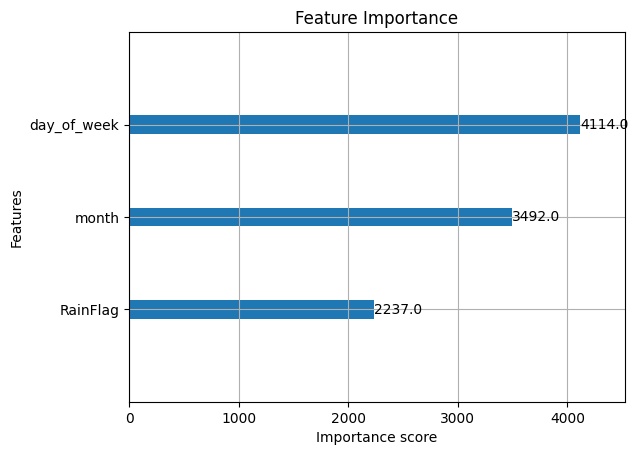

In [37]:
############################
# MERGE WEATHER + REVIEWS
############################

review_weather_density = review_density.merge(
    weather_df[["date","RainFlag","ColdFlag"]],
    on="date",
    how="left"
)

############################
# FEATURE ENGINEERING
############################

review_weather_density["day_of_week"] = pd.to_datetime(review_weather_density["date"]).dt.dayofweek
review_weather_density["month"] = pd.to_datetime(review_weather_density["date"]).dt.month
review_weather_density["weekend"] = (review_weather_density["day_of_week"] >= 5).astype(int)

############################
# DEFINE ML FEATURES
############################

X = review_weather_density[
    ["day_of_week","month","weekend","RainFlag"]
]

y = review_weather_density["review_count"]

############################
# TRAIN / TEST SPLIT
############################

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

############################
# TRAIN XGBOOST MODEL
############################

model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

############################
# MODEL EVALUATION
############################

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

############################
# PREDICT REVIEW DENSITY
############################

review_weather_density["predicted_review_count"] = model.predict(X)

############################
# CONVERT REVIEWS → VISITORS
############################
# Based on tourism research:
# average participation rate ≈ 0.078%

participation_rate = 0.00078

review_weather_density["estimated_visitors"] = (
    review_weather_density["predicted_review_count"] / participation_rate
)

############################
# CLASSIFY ATTRACTION TYPE
############################

def classify_attraction(name):

    name = name.lower()

    if "beach" in name:
        return "beach"

    elif "park" in name:
        return "park"

    elif "museum" in name:
        return "museum"

    elif "zoo" in name:
        return "zoo"

    elif "wine" in name:
        return "tour"

    elif "whale" in name:
        return "tour"

    elif "tour" in name:
        return "tour"

    elif "adventure" in name:
        return "activity"

    else:
        return "general"


top100["type"] = top100["name"].apply(classify_attraction)

############################
# MERGE TYPE INTO REVIEW DATA
############################

review_weather_density = review_weather_density.merge(
    top100[["business_id","type"]],
    on="business_id",
    how="left"
)

############################
# CAPACITY MODEL
############################

capacity_table = {
    "beach": 5000,
    "park": 3000,
    "museum": 800,
    "zoo": 700,
    "tour": 200,
    "activity": 150,
    "general": 500
}

base_wait_table = {
    "beach": 2,
    "park": 3,
    "museum": 8,
    "zoo": 10,
    "tour": 20,
    "activity": 25,
    "general": 10
}

############################
# WAITING TIME FUNCTION
############################

def compute_waiting(row):

    visitors = row["estimated_visitors"]
    attraction_type = row["type"]

    capacity = capacity_table.get(attraction_type,500)
    base_wait = base_wait_table.get(attraction_type,10)

    wait = base_wait * np.log1p(visitors / capacity)

    # stochastic queue fluctuation
    noise = np.random.lognormal(mean=0, sigma=0.25)

    wait = wait * noise

    return wait

############################
# CALCULATE WAITING TIME
############################

review_weather_density["waiting_time"] = review_weather_density.apply(
    compute_waiting,
    axis=1
)

# Clamp to realistic limits
review_weather_density["waiting_time"] = review_weather_density["waiting_time"].clip(1,120)

print(
    review_weather_density[
        ["date","review_count","predicted_review_count","estimated_visitors","waiting_time"]
    ].head()
)

############################
# AVERAGE WAITING TIME PER ATTRACTION
############################

waiting_time_avg = (
    review_weather_density
    .groupby("business_id")["waiting_time"]
    .mean()
    .reset_index()
)

############################
# MERGE WITH ATTRACTIONS
############################

top100_with_waiting_time = top100.merge(
    waiting_time_avg,
    on="business_id",
    how="left"
)

print(top100_with_waiting_time[["name","type","waiting_time"]].head())

############################
# FEATURE IMPORTANCE
############################

xgb.plot_importance(model)
plt.title("Feature Importance")
plt.show()

## 6. Then we really dive into the optimization work!

In [38]:
!pip3.12 install ortools

In [39]:
from ortools.linear_solver import pywraplp

n = len(top100_with_waiting_time)

In [40]:
########################################
# REAL-TIME WEATHER → WAITING PREDICTION
########################################

import requests
from datetime import datetime

lat = top100_with_waiting_time["latitude"].mean()
lon = top100_with_waiting_time["longitude"].mean()

weather_url = "https://api.open-meteo.com/v1/forecast"

weather_params = {
    "latitude": lat,
    "longitude": lon,
    "current_weather": True,
    "hourly": "precipitation_probability",
    "forecast_days": 1
}

response = requests.get(weather_url, params=weather_params)
weather_now = response.json()

# Build real-time feature vector
now = datetime.now()

day_of_week = now.weekday()
month = now.month
weekend = int(day_of_week >= 5)

RainFlag = int(weather_now["hourly"]["precipitation_probability"][0] > 50)

X_live = pd.DataFrame({
    "day_of_week":[day_of_week],
    "month":[month],
    "weekend":[weekend],
    "RainFlag":[RainFlag]
})

# Predict review density using trained XGBoost model
pred_review_density = model.predict(X_live)[0]

# Convert review density → visitors
participation_rate = 0.00078
estimated_visitors_live = pred_review_density / participation_rate

########################################
# REAL-TIME WAITING TIME
########################################

live_waiting = []

for t in top100_with_waiting_time["type"]:

    capacity = capacity_table.get(t, 500)
    base_wait = base_wait_table.get(t, 10)

    wait = base_wait * np.log1p(estimated_visitors_live / capacity)

    live_waiting.append(wait)

top100_with_waiting_time["waiting_time_live"] = live_waiting

########################################
# FINAL WAITING TIME (BLENDED)
########################################

top100_with_waiting_time["waiting_final"] = (
    0.7 * top100_with_waiting_time["waiting_time"] +
    0.3 * top100_with_waiting_time["waiting_time_live"]
)

In [41]:
############################
# COST ESTIMATION
############################

# Simple heuristic ticket price by attraction type
cost_table = {
    "beach": 0,
    "park": 5,
    "museum": 25,
    "zoo": 35,
    "tour": 50,
    "activity": 40,
    "general": 20
}

top100_with_waiting_time["cost"] = top100_with_waiting_time["type"].map(cost_table).fillna(20)



In [42]:
### Normalize features for better interpretability
from sklearn.preprocessing import MinMaxScaler
utility = top100_with_waiting_time["utility"].values
waiting_time = top100_with_waiting_time["waiting_final"].values
visiting_time = top100_with_waiting_time["visit_duration_sim"].values
cost = top100_with_waiting_time["cost"].values
scaler = MinMaxScaler()
utility_norm = scaler.fit_transform(utility.reshape(-1,1)).flatten()
waiting_time_norm = scaler.fit_transform(waiting_time.reshape(-1,1)).flatten()
visiting_time_norm = scaler.fit_transform(visiting_time.reshape(-1,1)).flatten()
cost_norm = scaler.fit_transform(cost.reshape(-1, 1)).flatten()
# Add the nonlinear term
p = 0.7
cost_penalty = cost_norm ** p
print("Utility (normalized):", utility_norm[:5].flatten())
print("Waiting Time (normalized):", waiting_time_norm[:5].flatten())
print("Visiting Time (normalized):", visiting_time_norm[:5].flatten())

# Avoid too many the same kind of places to visit by adding a penalty for similar categories
wine_indices = [i for i,row in top100_with_waiting_time.iterrows() if "Wine" in row["name"]]
whale_indices = [i for i,row in top100_with_waiting_time.iterrows() if "Whale" in row["name"]]


tourist_profiles = {

    "relaxed": {
        "alpha": 3.0,
        "beta": 0.8,
        "min_attractions": 2,
        "max_attractions": 5,
        "max_wait": 60
    },

    "balanced": {
        "alpha": 2.0,
        "beta": 1.0,
        "min_attractions": 3,
        "max_attractions": 6,
        "max_wait": 90
    },

    "explorer": {
        "alpha": 1.0,
        "beta": 0.9,
        "min_attractions": 4,
        "max_attractions": 10,
        "max_wait": 180
    }
}

T = 720  # Total time in minutes (12 hours)

d = travel_time_matrix

travel_norm = (d - d.min()) / (d.max() - d.min())

routes = {}
edges = {}

B = 120   # total budget (dollars)
gamma = 0.01  # cost penalty weight

for profile in tourist_profiles:

    solver = pywraplp.Solver.CreateSolver("SCIP")

    alpha = tourist_profiles[profile]["alpha"]
    beta = tourist_profiles[profile]["beta"]

    x = [solver.BoolVar(f"x_{i}") for i in range(n)]
    y = {}

    for i in range(n):
        for j in range(n):
            if i != j:
                y[i,j] = solver.BoolVar(f"y_{i}_{j}")
    place_bonus = 0

    if profile == "explorer":
        place_bonus = 0.3
    elif profile == "balanced":
        place_bonus = 0.05
    arc_list = list(y.keys())

    objective = (
        solver.Sum(utility_norm[i] * x[i] for i in range(n))
        - alpha * solver.Sum(waiting_time_norm[i] * x[i] for i in range(n))
        - beta * solver.Sum(travel_norm[i][j] * y[i,j] for (i,j) in arc_list)
        - gamma * solver.Sum(cost_penalty[i] * x[i] for i in range(n))
        + place_bonus * solver.Sum(x[i] for i in range(n))
    )

    solver.Maximize(objective)
    # Add time constraint (e.g., total time ≤ 12 hours = 720 minutes)

    solver.Add(

    solver.Sum((visiting_time[i] + 0.8*waiting_time[i]) * x[i] for i in range(n)) # Tourists experience the waiting inside the visiting as well.

    + solver.Sum(d[i][j] * y[i,j]
                 for i in range(n)
                 for j in range(n)
                 if i != j)

    <= T)

    # Budget constraint
    solver.Add(
    solver.Sum(cost[i] * x[i] for i in range(n)) <= B)
    # # Add start location constraint (e.g., start at attraction 0)
    solver.Add(x[0] == 1)
    solver.Add(solver.Sum(y[0,j] for j in range(n) if (0,j) in y) == 1)
    # Add attraction category penalty constraints (e.g., no more than 2 wine-related attractions)
    solver.Add(solver.Sum(x[i] for i in wine_indices) <= 2)
    solver.Add(solver.Sum(x[i] for i in whale_indices) <= 2)
    # Add attraction count constraint(min and max)
    solver.Add(solver.Sum(x[i] for i in range(n)) >= tourist_profiles[profile]["min_attractions"])
    solver.Add(solver.Sum(x[i] for i in range(n)) <= tourist_profiles[profile]["max_attractions"])
    # Add waiting time constraint
    solver.Add(solver.Sum(waiting_time[i] * x[i] for i in range(n))
    <= tourist_profiles[profile]["max_wait"] *
       tourist_profiles[profile]["max_attractions"])

    # Add flow constraints to ensure consistency between x and y
    for i in range(n):

        solver.Add(
            solver.Sum(y[i,j] for j in range(n) if i != j) == x[i])


    for j in range(n):

        solver.Add(
            solver.Sum(y[i,j] for i in range(n) if i != j) == x[j])
    # Each node visited at most once
    for i in range(n):
        solver.Add(
            solver.Sum(y[i,j] for j in range(n) if i != j) <= 1
        )
    # Add MTZ constraints
    max_k = tourist_profiles[profile]["max_attractions"]

    u = [solver.NumVar(0, max_k, f"u_{i}") for i in range(n)]

    solver.Add(u[0] == 0)

    for (i,j) in y:
        if i != 0 and j != 0:
            solver.Add(
                u[i] - u[j] + max_k * y[i,j] <= max_k - 1)
    solver.EnableOutput()
    status = solver.Solve()


    if status == pywraplp.Solver.OPTIMAL:

        selected = [i for i in range(n) if x[i].solution_value() > 0.5]
        routes[profile] = selected

        edge_list = []
        for (i,j) in y:
            if y[i,j].solution_value() > 0.5:
                edge_list.append((i,j))

        edges[profile] = edge_list
        print("=" * 40)
        print("Selected attractions:")
        print(f"**{profile.capitalize()}**: {top100_with_waiting_time.iloc[selected][['name','utility','waiting_time']]}")

        total_time = sum(visiting_time[i] + waiting_time[i] for i in selected)
        print("Total itinerary time:", total_time)

Utility (normalized): [0.84584577 1.         0.7063136  0.83324704 0.82431582]
Waiting Time (normalized): [0.17549111 0.69759329 0.21376378 0.69888308 0.21522845]
Visiting Time (normalized): [0.62672669 0.48165113 0.37944034 0.75553684 0.60335596]
Selected attractions:
**Relaxed**:                                 name    utility  waiting_time
0                  Santa Barbara Zoo  26.100119     11.290802
8                 Arroyo Burro Beach  24.882431      1.000941
46                    Shoreline Park  19.884783      1.198083
50  Alice Keck Park Memorial Gardens  19.719120      1.190730
56                      Alameda Park  18.853446      1.189796
Total itinerary time: 444.50410572740975
Selected attractions:
**Balanced**:                                 name    utility  waiting_time
0                  Santa Barbara Zoo  26.100119     11.290802
8                 Arroyo Burro Beach  24.882431      1.000941
46                    Shoreline Park  19.884783      1.198083
50  Alice Keck Park 

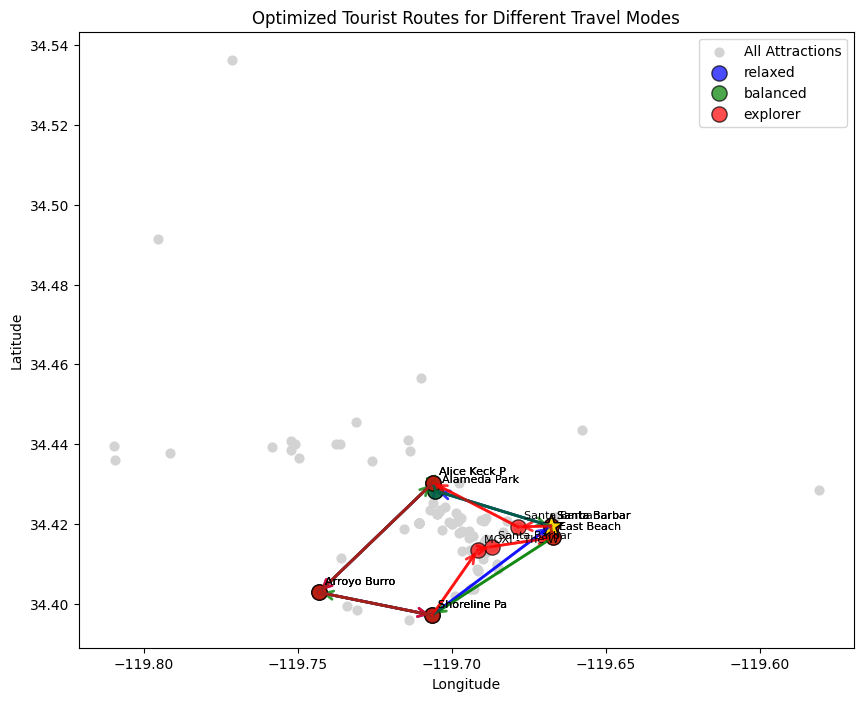

In [43]:
plt.figure(figsize=(10,8))

# plot all attractions
plt.scatter(
    top100_with_waiting_time["longitude"],
    top100_with_waiting_time["latitude"],
    c="lightgray",
    label="All Attractions",
    s=40
)

colors = {
    "relaxed": "blue",
    "balanced": "green",
    "explorer": "red"
}

for profile in routes:

    selected = routes[profile]
    edge_list = edges[profile]

    # ---- find start node (node with no incoming edge) ----
    incoming = {j for (_, j) in edge_list}
    start_nodes = [i for i in selected if i not in incoming]

    if len(start_nodes) > 0:
        start = start_nodes[0]
    else:
        start = selected[0]

    # ---- plot nodes ----
    plt.scatter(
        top100_with_waiting_time.iloc[selected]["longitude"],
        top100_with_waiting_time.iloc[selected]["latitude"],
        c=colors[profile],
        label=profile,
        s=120,
        alpha=0.7,
        edgecolor="black"
    )

    # ---- plot start node ----
    plt.scatter(
        top100_with_waiting_time.iloc[start]["longitude"],
        top100_with_waiting_time.iloc[start]["latitude"],
        marker="*",
        s=300,
        c="gold",
        edgecolor="black"
    )

    # ---- plot travel edges with arrows ----


    for i, j in edge_list:

        lon1 = top100_with_waiting_time.iloc[i]["longitude"]
        lat1 = top100_with_waiting_time.iloc[i]["latitude"]

        lon2 = top100_with_waiting_time.iloc[j]["longitude"]
        lat2 = top100_with_waiting_time.iloc[j]["latitude"]

        plt.plot(
            [lon1, lon2],
            [lat1, lat2],
            color=colors[profile],
            linewidth=2,
            alpha=0.6
        )

        arrow = FancyArrowPatch(
            (lon1, lat1),
            (lon2, lat2),
            arrowstyle="->",
            mutation_scale=15,
            color=colors[profile],
            linewidth=2,
            alpha=0.8
        )

        plt.gca().add_patch(arrow)

    # ---- label attractions ----
    for i in selected:

        row = top100_with_waiting_time.iloc[i]

        plt.text(
            row["longitude"] + 0.002,
            row["latitude"] + 0.002,
            row["name"][:12],
            fontsize=8
        )

plt.legend()
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Optimized Tourist Routes for Different Travel Modes")

plt.show()

In [44]:
print("Objective value:", solver.Objective().Value())

Objective value: 6.039484050377633


In [45]:
print(profile, "edges:", edge_list)

explorer edges: [(0, 37), (8, 46), (23, 55), (37, 50), (46, 23), (50, 8), (55, 60), (60, 0)]


In [46]:
utility_gain = sum(utility_norm[i] for i in selected)
waiting_penalty = sum(waiting_time_norm[i] for i in selected)

print("Utility:", utility_gain)
print("Waiting penalty:", waiting_penalty)

Utility: 5.106907012164564
Waiting penalty: 0.731172464336931


We make an interative map:

In [47]:
import openrouteservice
client = openrouteservice.Client(key="eyJvcmciOiI1YjNjZTM1OTc4NTExMTAwMDFjZjYyNDgiLCJpZCI6ImM1ZDk5NDRlMTI3ZDQzOTJhNGQ3MzRjNGI1ZDJlMGQyIiwiaCI6Im11cm11cjY0In0=")

In [48]:
def get_route(lon1, lat1, lon2, lat2):

    coords = [(lon1, lat1), (lon2, lat2)]

    route = client.directions(
        coordinates=coords,
        profile='driving-car',
        format='geojson'
    )

    return route['features'][0]['geometry']['coordinates']

In [49]:
def reconstruct_route(edge_list):

    next_node = {i:j for i,j in edge_list}

    start = edge_list[0][0]   # pick arbitrary start

    route = [start]
    current = start

    while True:
        current = next_node.get(current)

        if current is None or current == start:
            break

        route.append(current)

    return route

In [50]:
import folium
from folium.plugins import PolyLineTextPath
from folium.plugins import HeatMap
from folium.plugins import AntPath
# map center
center_lat = top100_with_waiting_time["latitude"].mean()
center_lon = top100_with_waiting_time["longitude"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=13,
    tiles="cartodbpositron"
)

colors = {
    "relaxed": "#0072B2",
    "balanced": "green",
    "explorer": "red"
}

# create toggleable layers
layers = {
    "relaxed": folium.FeatureGroup(name="Relaxed"),
    "balanced": folium.FeatureGroup(name="Balanced"),
    "explorer": folium.FeatureGroup(name="Explorer")
}


heat_data = []

for i, row in top100_with_waiting_time.iterrows():

    heat_data.append([
        row["latitude"],
        row["longitude"],
        row["utility"]   # weight
    ])

heat_layer = folium.FeatureGroup(name="Attraction Heatmap")

HeatMap(
    heat_data,
    radius=25,
    blur=20,
    max_zoom=13
).add_to(heat_layer)

heat_layer.add_to(m)

for profile in routes:

    selected = reconstruct_route(edges[profile])
    selected = [int(i) for i in selected]   # ensure integer indices

    color = colors[profile]
    layer = layers[profile]

    # -------------------
    # Attraction markers
    # -------------------
for profile in routes:

    selected = reconstruct_route(edges[profile])
    selected = [int(i) for i in selected]

    color = colors[profile]
    layer = layers[profile]

    # markers
    for order, i in enumerate(selected, start=1):

        row = top100_with_waiting_time.iloc[i]

        popup_text = f"""
        <b>{order}. {row['name']}</b><br>
        Utility: {row['utility']:.2f}<br>
        Waiting time: {row['waiting_time']:.1f} min
        """

        folium.Marker(
            location=[row["latitude"], row["longitude"]],
            popup=folium.Popup(popup_text, max_width=250),
            tooltip=f"{order}. {row['name']}",
            icon=folium.DivIcon(
                html=f"""
                <div style="
                    background-color:{color};
                    color:white;
                    border-radius:50%;
                    width:28px;
                    height:28px;
                    text-align:center;
                    font-weight:bold;
                    line-height:28px;">
                    {order}
                </div>
                """
            )
        ).add_to(layer)

    # routing
    coords = []

    for i in selected:
        row = top100_with_waiting_time.iloc[i]
        coords.append((row["longitude"], row["latitude"]))

    route = client.directions(
        coordinates=coords,
        profile="foot-walking",
        format="geojson"
    )

    geometry = route["features"][0]["geometry"]["coordinates"]
    route_latlon = [(lat, lon) for lon, lat in geometry]

    AntPath(
        locations=route_latlon,
        color=color,
        weight=6,
        delay=800,
        dash_array=[15,25],
        pulse_color="white",
    ).add_to(layer)

    # start node
    start = selected[0]
    row = top100_with_waiting_time.iloc[start]

    folium.Marker(
        location=[row["latitude"], row["longitude"]],
        icon=folium.Icon(color="orange", icon="star"),
        popup=f"Start ({profile})"
    ).add_to(layer)

    # THIS IS THE CRITICAL LINE
    layer.add_to(m)

    # -------- return to start --------
    return_start = selected[-1]
    return_end = selected[0]

    row1 = top100_with_waiting_time.iloc[return_start]
    row2 = top100_with_waiting_time.iloc[return_end]

    route_back = client.directions(
        coordinates=[
            (row1["longitude"], row1["latitude"]),
            (row2["longitude"], row2["latitude"])
        ],
        profile="foot-walking",
        format="geojson"
    )

    geometry_back = route_back["features"][0]["geometry"]["coordinates"]
    route_back_latlon = [(lat, lon) for lon, lat in geometry_back]

    AntPath(
        locations=route_back_latlon,
        color=color,
        weight=6,
        delay=800,
        dash_array=[10,20],
        pulse_color="white"
    ).add_to(layer)
    # -------------------
    # Real road routing
    # -------------------
    coords = []

    for i in selected:
        row = top100_with_waiting_time.iloc[i]
        coords.append((row["longitude"], row["latitude"]))

    # add return to start
    start = selected[0]
    row = top100_with_waiting_time.iloc[start]
    coords.append((row["longitude"], row["latitude"]))

    route = client.directions(
        coordinates=coords,
        profile="foot-walking",
        format="geojson"
    )

    geometry = route["features"][0]["geometry"]["coordinates"]

    route_latlon = [(lat, lon) for lon, lat in geometry]

    folium.PolyLine(
        locations=route_latlon,
        color=color,
        weight=6,
        opacity=0.7
    ).add_to(layer)

    # -------------------
    # Start node
    # -------------------
    start = selected[0]
    row = top100_with_waiting_time.iloc[start]

    folium.Marker(
        location=[row["latitude"], row["longitude"]],
        icon=folium.Icon(color="orange", icon="star"),
        popup=f"Start ({profile})"
    ).add_to(layer)

    layer.add_to(m)


# layer control checkbox
folium.LayerControl().add_to(m)
legend_html = """
<div style="
position: fixed;
bottom: 50px;
left: 50px;
width: 180px;
background-color: white;
border:2px solid grey;
z-index:9999;
font-size:14px;
padding:10px;
">

<b>Tourist Profiles</b><br>
<span style="color:blue;">●</span> Relaxed<br>
<span style="color:green;">●</span> Balanced<br>
<span style="color:red;">●</span> Explorer<br>
🔥 Heatmap<br>
⭐ Start Point
</div>
"""

m.get_root().html.add_child(folium.Element(legend_html))

m.save("tourist_routes_map.html")